In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset/Cancer_Data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
df.isnull().sum() / df.shape[0] * 100

id                           0.0
diagnosis                    0.0
radius_mean                  0.0
texture_mean                 0.0
perimeter_mean               0.0
area_mean                    0.0
smoothness_mean              0.0
compactness_mean             0.0
concavity_mean               0.0
concave points_mean          0.0
symmetry_mean                0.0
fractal_dimension_mean       0.0
radius_se                    0.0
texture_se                   0.0
perimeter_se                 0.0
area_se                      0.0
smoothness_se                0.0
compactness_se               0.0
concavity_se                 0.0
concave points_se            0.0
symmetry_se                  0.0
fractal_dimension_se         0.0
radius_worst                 0.0
texture_worst                0.0
perimeter_worst              0.0
area_worst                   0.0
smoothness_worst             0.0
compactness_worst            0.0
concavity_worst              0.0
concave points_worst         0.0
symmetry_w

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns = df.columns.str.upper()

In [7]:
df.head()

,ID,DIAGNOSIS,RADIUS_MEAN,TEXTURE_MEAN,PERIMETER_MEAN,AREA_MEAN,SMOOTHNESS_MEAN,COMPACTNESS_MEAN,CONCAVITY_MEAN,CONCAVE POINTS_MEAN,...,TEXTURE_WORST,PERIMETER_WORST,AREA_WORST,SMOOTHNESS_WORST,COMPACTNESS_WORST,CONCAVITY_WORST,CONCAVE POINTS_WORST,SYMMETRY_WORST,FRACTAL_DIMENSION_WORST,UNNAMED: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
df = df.drop(columns=['ID'])

In [9]:
df['DIAGNOSIS'] = df['DIAGNOSIS'].map({'M': 1, 'B': 0})

In [10]:
corr = df.corr()

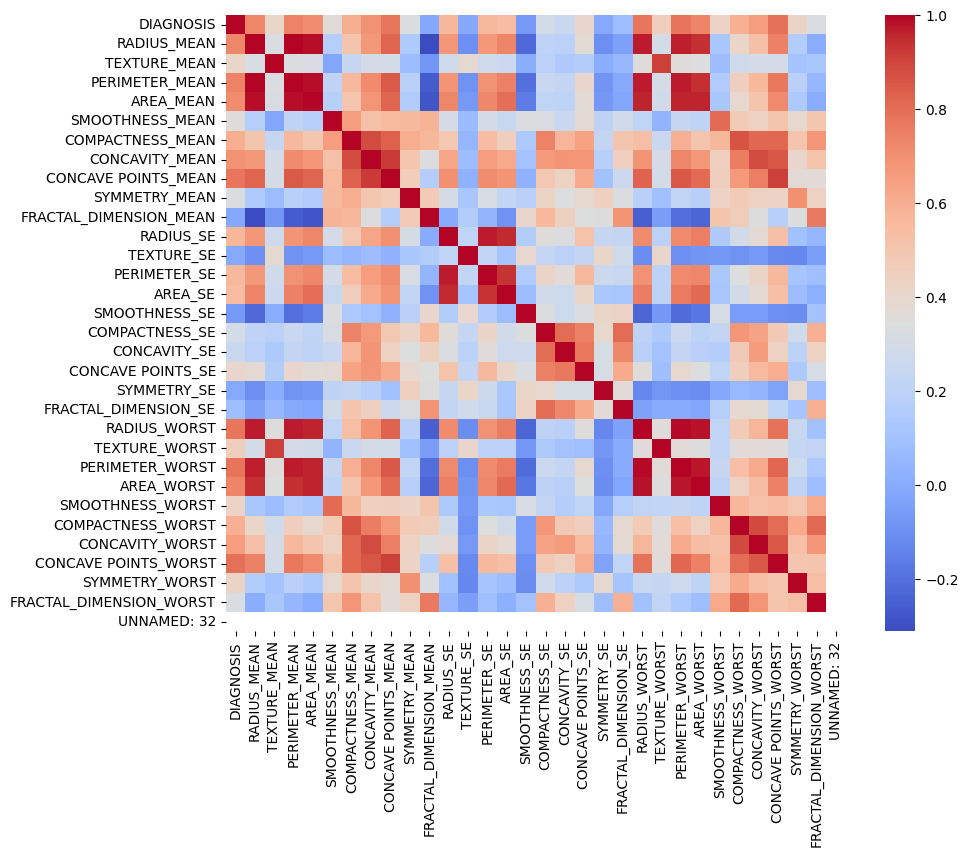

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [12]:
corr = df.corr()

corr_target = corr['DIAGNOSIS'].abs().sort_values(ascending=False)
corr_target

DIAGNOSIS                  1.000000
CONCAVE POINTS_WORST       0.793566
PERIMETER_WORST            0.782914
CONCAVE POINTS_MEAN        0.776614
RADIUS_WORST               0.776454
PERIMETER_MEAN             0.742636
AREA_WORST                 0.733825
RADIUS_MEAN                0.730029
AREA_MEAN                  0.708984
CONCAVITY_MEAN             0.696360
CONCAVITY_WORST            0.659610
COMPACTNESS_MEAN           0.596534
COMPACTNESS_WORST          0.590998
RADIUS_SE                  0.567134
PERIMETER_SE               0.556141
AREA_SE                    0.548236
TEXTURE_WORST              0.456903
SMOOTHNESS_WORST           0.421465
SYMMETRY_WORST             0.416294
TEXTURE_MEAN               0.415185
CONCAVE POINTS_SE          0.408042
SMOOTHNESS_MEAN            0.358560
SYMMETRY_MEAN              0.330499
FRACTAL_DIMENSION_WORST    0.323872
COMPACTNESS_SE             0.292999
CONCAVITY_SE               0.253730
FRACTAL_DIMENSION_SE       0.077972
SMOOTHNESS_SE              0

In [13]:
selected_features = [
    'RADIUS_MEAN',
    'TEXTURE_MEAN',
    'PERIMETER_MEAN',
    'AREA_MEAN',
    'CONCAVITY_MEAN',
    'CONCAVE_POINTS_MEAN'
]

In [14]:
df.columns.tolist()

['DIAGNOSIS',
 'RADIUS_MEAN',
 'TEXTURE_MEAN',
 'PERIMETER_MEAN',
 'AREA_MEAN',
 'SMOOTHNESS_MEAN',
 'COMPACTNESS_MEAN',
 'CONCAVITY_MEAN',
 'CONCAVE POINTS_MEAN',
 'SYMMETRY_MEAN',
 'FRACTAL_DIMENSION_MEAN',
 'RADIUS_SE',
 'TEXTURE_SE',
 'PERIMETER_SE',
 'AREA_SE',
 'SMOOTHNESS_SE',
 'COMPACTNESS_SE',
 'CONCAVITY_SE',
 'CONCAVE POINTS_SE',
 'SYMMETRY_SE',
 'FRACTAL_DIMENSION_SE',
 'RADIUS_WORST',
 'TEXTURE_WORST',
 'PERIMETER_WORST',
 'AREA_WORST',
 'SMOOTHNESS_WORST',
 'COMPACTNESS_WORST',
 'CONCAVITY_WORST',
 'CONCAVE POINTS_WORST',
 'SYMMETRY_WORST',
 'FRACTAL_DIMENSION_WORST',
 'UNNAMED: 32']

In [15]:
df = df.drop(columns=['UNNAMED: 32'])

In [16]:
df.columns

Index(['DIAGNOSIS', 'RADIUS_MEAN', 'TEXTURE_MEAN', 'PERIMETER_MEAN',
       'AREA_MEAN', 'SMOOTHNESS_MEAN', 'COMPACTNESS_MEAN', 'CONCAVITY_MEAN',
       'CONCAVE POINTS_MEAN', 'SYMMETRY_MEAN', 'FRACTAL_DIMENSION_MEAN',
       'RADIUS_SE', 'TEXTURE_SE', 'PERIMETER_SE', 'AREA_SE', 'SMOOTHNESS_SE',
       'COMPACTNESS_SE', 'CONCAVITY_SE', 'CONCAVE POINTS_SE', 'SYMMETRY_SE',
       'FRACTAL_DIMENSION_SE', 'RADIUS_WORST', 'TEXTURE_WORST',
       'PERIMETER_WORST', 'AREA_WORST', 'SMOOTHNESS_WORST',
       'COMPACTNESS_WORST', 'CONCAVITY_WORST', 'CONCAVE POINTS_WORST',
       'SYMMETRY_WORST', 'FRACTAL_DIMENSION_WORST'],
      dtype='str')

In [17]:
selected_features = [
    'RADIUS_MEAN',
    'TEXTURE_MEAN',
    'PERIMETER_MEAN',
    'AREA_MEAN',
    'CONCAVITY_MEAN',
    'CONCAVE POINTS_MEAN'
]

X = df[selected_features]
y = df['DIAGNOSIS']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
#Logistic Regression 

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.956140350877193


In [22]:
#Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.956140350877193


In [24]:
#Support Vector Machine

In [25]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf',probability=True)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9736842105263158


In [26]:
#K-Nearest Neighbors (KNN)

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9473684210526315


In [28]:
#Gradient Boosting

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9473684210526315


In [30]:
import joblib

joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']